In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import time
import os
from scipy.optimize import curve_fit
import B00_codes.dataReader as dr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
import matplotlib.colors as mcolors
import json
from scipy.special import jn
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from lmfit import Model, Parameters, minimize
from scipy.integrate import dblquad

NO_MS_EQUALS_1 = 0
Q_FINAL = 1
THREE_PI_HALF_FINAL = 2
REF_MINUS_SIG  =3
f0 = 2.88e9

pi = np.pi

def right_circular_shift(arr, k):
    n = len(arr)
    k = k % n  # To handle cases where k is larger than the array length
    return np.concatenate((arr[-k:], arr[:-k]))
def left_circular_shift(arr, k):
    n = len(arr)
    k = k % n  # To handle cases where k is larger than the array length
    return np.concatenate((arr[k:], arr[:k]))

def chi_squared(y, y_fit, sigma):
    residuals = y - y_fit
    return np.sum((residuals / sigma)**2)

def reduced_chi_squared(y, y_fit, sigma, popt, pcov):
    n = len(y)  # Number of data points
    p = len(popt)  # Number of fitting parameters
    dof = n - p  # Degrees of freedom
    chisq = chi_squared(y, y_fit, sigma)  # Chi-squared value
    reduced_chisq = chisq / dof
    return reduced_chisq

def running_average(arr):
    running_sum = 0
    running_avg = []

    for i, num in enumerate(arr):
        running_sum += num
        avg = running_sum / (i + 1)  # Calculate the running average
        running_avg.append(avg)

    return running_avg

def smooth(x, n=3):
    K = int((n-1)/2)
    smoothed_x = np.zeros(len(x))
    for i in range(K):
        smoothed_x[i] = x[i]
        smoothed_x[-i-1] = x[-i-1]
    for i in range(0, len(x)-(n-1)):
        for j in range(n):
            smoothed_x[i+K] += x[i+j]/n
    return smoothed_x

def smoothConvolution(x, n=5):
    K = int((n-1)/2)
    mask = np.ones(n)/n
    z = np.convolve(x,mask,'same')
    z[-K:] = x[-K:]
    return z

def average(y, n):
    # Initialize an empty list to store the averages
    averages = []

    # Iterate through the array in steps of 3
    for i in range(0, len(y), n):
        group = y[i:i + n]  # Get a group of three points
        average = np.mean(group)  # Calculate the average of the group
        averages.append(average)  # Add the average to the list

    # Convert the list of averages back to a NumPy array
    return np.array(averages)

def cov(a,b,axis=1):
    if len(np.shape(a))==2:
        N = np.shape(a)[1]
    else:
        N = np.shape(a)[0]
    prod = a*b
    # prod = np.nan_to_num(prod)
    prodavg = np.nanmean(prod,axis=axis)
    aavg = np.nanmean(a,axis=axis)
    bavg = np.nanmean(b,axis=axis)
    sigma_a = np.nanstd(a, axis=axis)
    sigma_b = np.nanstd(b, axis=axis)
    
    r = (prodavg - aavg*bavg)/(sigma_a * sigma_b)
    sigma_r = np.sqrt((1-r**2)/(N-2))
    return r, sigma_r, aavg,sigma_a

def covmask(a, b, axis=1,thres=3):
    if len(np.shape(a)) == 2:
        N = np.shape(a)[1]
    else:
        N = np.shape(a)[0]

    prod = a*b
    mask = prod >= thres
    
    prod       = np.where(mask, prod, np.nan)
    a_filtered = np.where(mask, a, np.nan)
    b_filtered = np.where(mask, b, np.nan)
    
    # Calculate the product of filtered arrays
    # prod = a_filtered * b_filtered
    # prod = np.nan_to_num(prod)  # Replace NaN with 0s in the product
    
    # Compute the averages and standard deviations ignoring NaNs
    prodavg = np.nanmean(prod, axis=axis)
    aavg = np.nanmean(a_filtered, axis=axis)
    bavg = np.nanmean(b_filtered, axis=axis)
    sigma_a = np.nanstd(a_filtered, axis=axis)
    sigma_b = np.nanstd(b_filtered, axis=axis)
    
    # Compute the correlation coefficient and its standard deviation
    r = (prodavg - aavg * bavg) / (sigma_a * sigma_b)
    sigma_r = np.sqrt((1 - r**2) / (N - 2))
    
    return r, sigma_r, aavg, sigma_a

def covmaskOriginal(a, b, axis=1,thres=3):
    if len(np.shape(a)) == 2:
        N = np.shape(a)[1]
    else:
        N = np.shape(a)[0]
    
    # Mask the arrays, setting elements < 3 to NaN
    mask_a = a >= thres
    mask_b = b >= thres
    
    # Apply the mask (set elements < 3 to NaN)
    a_filtered = np.where(mask_a, a, np.nan)
    b_filtered = np.where(mask_b, b, np.nan)
    
    # Calculate the product of filtered arrays
    prod = a_filtered * b_filtered
    prod = np.nan_to_num(prod)  # Replace NaN with 0s in the product
    
    # Compute the averages and standard deviations ignoring NaNs
    prodavg = np.nanmean(prod, axis=axis)
    aavg = np.nanmean(a_filtered, axis=axis)
    bavg = np.nanmean(b_filtered, axis=axis)
    sigma_a = np.nanstd(a_filtered, axis=axis)
    sigma_b = np.nanstd(b_filtered, axis=axis)
    
    # Compute the correlation coefficient and its standard deviation
    r = (prodavg - aavg * bavg) / (sigma_a * sigma_b)
    sigma_r = np.sqrt((1 - r**2) / (N - 2))
    
    return r, sigma_r, aavg, sigma_a

def thresholded(sig,thres):
    (row, col) = np.shape(sig)

    sigThd = np.zeros((row, col))
    for i in range(row):
        for j in range(col):
            if np.isnan(sig[i,j]): 
                sigThd[i,j] = np.nan
            elif sig[i,j] > thres: 
                sigThd[i,j] = 1
    return sigThd

def contrast_new(sigs,refs,sigavg,refavg,ifNorm=0,max_contrast=1):
    (row, col) = np.shape(sigs)
    contrast = np.zeros((row,col))
    diff = sigs-refs
    for i in range(row):
        contrast[i] = diff[i]/(sigavg[i]+refavg[i])
    
    if ifNorm==1: # full contrast defined by data, usually for cosine magnetometry
        y = (sigavg-refavg)/(sigavg+refavg)
        contrast = linear_map(contrast,-max(y),max(y),0,1)
    elif ifNorm==2: # full contrast defined by prev calib
        y = (sigavg-refavg)/(sigavg+refavg)
        contrast = linear_map(contrast,-max_contrast,max_contrast,0,1)

    return contrast

def linear_map(arr, a, b, c, d): # map a to c, b to d
    return (arr - a) * (d - c) / (b - a) + c

def find_peaks(data, threshold=0):
    peaks = []
    for i in range(1, len(data) - 1):
        if data[i] > data[i - 1] and data[i] > data[i + 1] and data[i] > threshold:
            peaks.append(i)
    return peaks

def subtractMeanFewReps(array,n):
    reshaped_array = array.reshape(-1, n)
    mean_per_group = np.mean(reshaped_array, axis=1)
    mean_repeated  = np.repeat(mean_per_group, n)
    result_array   = array - mean_repeated
    return result_array

def fourier(y, delta_t, f_factor=1):
    yfourier = np.fft.fft(y-np.average(y)); yfourier = np.abs(yfourier)
    f = np.fft.fftfreq(len(y), delta_t)/f_factor  # insert spacing

    sorted_indices = np.argsort(f)       # Get the indices that would sort f
    f = f[sorted_indices]                # Sort f in ascending order
    yfourier = yfourier[sorted_indices]  # Reorder yfourier based on the sorted_indices

    return f,yfourier

def fourierReal(y, delta_t, f_factor=1):
    yfourier = np.fft.fft(y-np.average(y)); yfourier = np.real(yfourier)
    f = np.fft.fftfreq(len(y), delta_t)/f_factor  # insert spacing

    sorted_indices = np.argsort(f)       # Get the indices that would sort f
    f = f[sorted_indices]                # Sort f in ascending order
    yfourier = yfourier[sorted_indices]  # Reorder yfourier based on the sorted_indices

    return f,yfourier

def fourierNorm(y, delta_t, f_factor=1):
    yfourier = np.fft.fft(y-0*np.average(y)); yfourier = np.real(yfourier)
    f = np.fft.fftfreq(len(y), delta_t)/f_factor  # insert spacing

    sorted_indices = np.argsort(f)       # Get the indices that would sort f
    f = f[sorted_indices]                # Sort f in ascending order
    yfourier = yfourier[sorted_indices]  # Reorder yfourier based on the sorted_indices
    yfourier = yfourier/np.sum(np.abs(yfourier))
    return f,yfourier

def circular_shift(arr, shift_amount):
    n = len(arr)
    # Use modulo to handle circular shifting
    shifted_arr = np.concatenate((arr[-shift_amount % n:], arr[:-shift_amount % n]))
    return shifted_arr

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, offset):
    x, y = xy
    f = offset + amplitude * np.exp(
        -((x - x0) ** 2 / (2 * sigma_x ** 2) + (y - y0) ** 2 / (2 * sigma_y ** 2)))
    return f.ravel()

In [98]:
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_001_xz_-44_110.npy'; cfc = np.load(s)
x_array = np.linspace(-4,4, 61)
y_array = np.linspace(1,10, 121)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_002_xz_-66_100.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,101)
y_array = np.linspace(10,0,151)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_003_xz_-66_010.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,101)
y_array = np.linspace(0,10,151)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_004_xz_-66_100.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,201)
y_array = np.linspace(10,0,201)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_005_xz_-66_010.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,201)
y_array = np.linspace(0,10,201)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_006_xz_-66_010.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,151)
y_array = np.linspace(0,10,151)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_007_xz_-66_100.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,151)
y_array = np.linspace(10,0,151)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_008_xz_-66_010.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,201)
y_array = np.linspace(0,10,201)
s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_009_xy_-66_-66.npy'; cfc = np.load(s)
x_array = np.linspace(-6,6,81)
y_array = np.linspace(-6,6,81)
# s = 'C:/Users/lukin2dmaterials/data/2025-02-13/cfc_010_xy_-66_-66.npy'; cfc = np.load(s)
# x_array = np.linspace(-6,6,121)
# y_array = np.linspace(-6,6,121)

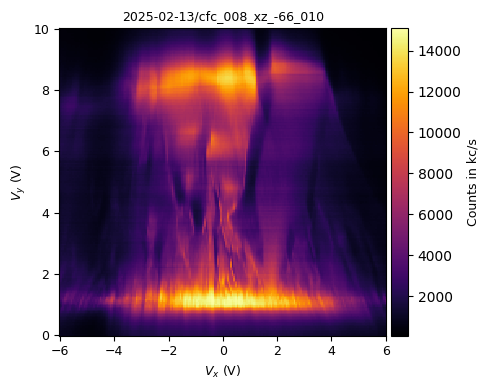

In [86]:
fig, ax = plt.subplots(figsize=(5,4))
fontsize = 9; convfactor = 1
start = 0; end = None
X,Y = np.meshgrid(x_array[start:end]*convfactor, y_array[start:end]*convfactor)
im = ax.pcolormesh(X, Y, cfc[start:end,start:end], cmap='inferno')

# im.set_clim([0,15000])

# plt.xlabel('$x$ ($\mu$m)', fontsize=fontsize)
# plt.ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.set_xlabel('$V_x$ (V)', fontsize=fontsize)
ax.set_ylabel('$V_y$ (V)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)

divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="5%", pad=0.05)
cb1 = fig.colorbar(im, orientation='vertical', ax=ax,cax=cbar_ax)
cb1.set_label("Counts in kc/s",fontsize=fontsize)

ax.set_title(s[31:-4],fontsize=fontsize)
plt.tight_layout()

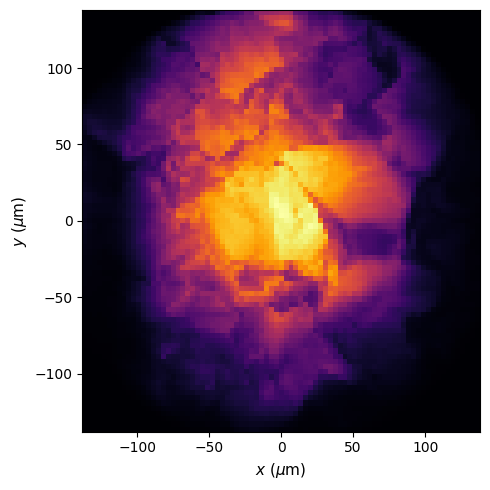

In [101]:
# For piza talk
fig, ax = plt.subplots(figsize=(5,5))
fontsize = 11; convfactorx = 1e3/44; convfactory = 1e3/44
start = 0; end = None
X,Y = np.meshgrid(x_array[start:end]*convfactorx, y_array[start:end]*convfactory)
im = ax.pcolormesh(X, Y, cfc[start:end,start:end], cmap='inferno')

# im.set_clim([0,15000])

plt.xlabel('$x$ ($\mu$m)', fontsize=fontsize)
plt.ylabel('$y$ ($\mu$m)', fontsize=fontsize)
# ax.set_xlabel('$V_x$ (V)', fontsize=fontsize)
# ax.set_ylabel('$V_y$ (V)', fontsize=fontsize)
# ax.tick_params(labelsize=fontsize)

# divider = make_axes_locatable(ax)
# cbar_ax = divider.append_axes("right", size="5%", pad=0.05)
# cb1 = fig.colorbar(im, orientation='vertical', ax=ax,cax=cbar_ax)
# cb1.set_label("Counts in kc/s",fontsize=fontsize)

# ax.set_title(s[31:-4],fontsize=fontsize)
plt.tight_layout()

In [94]:
fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/pizza_1.png', dpi=3600)